**Sentiment Analysis Results:**
**Overall Sentiment:**
Positive: 66.67%
Negative: 33.33%
**Top Positive Themes:**
Comfort: 0.00%
Service: 0.00%
Food: 0.00%
**Top Negative Themes:**
Delays: 0.00%
Customer Service: 0.00%
Baggage: 0.00%


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\princ\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


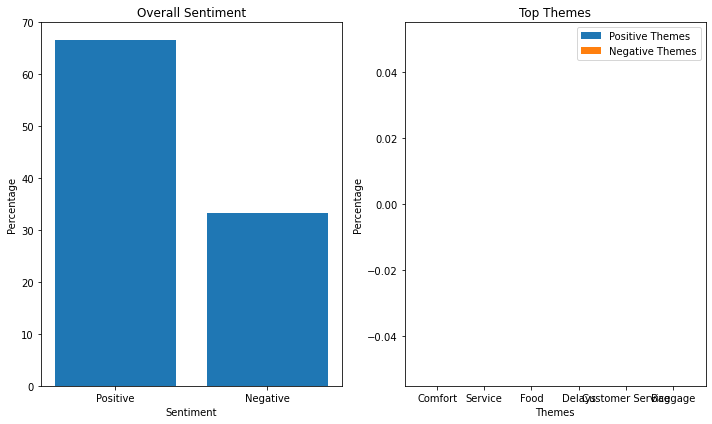

In [1]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the vader_lexicon resource
nltk.download('vader_lexicon')


# Load the data
file_path = r"C:\Users\princ\Desktop\PACE Docs\INSPIRE\Micro-Internship\BRITISH AIRWAYS\Airline Reviews\data\cleaned_data.csv"
df = pd.read_csv(file_path)
#df = pd.DataFrame('')

# Perform sentiment analysis
sia = SentimentIntensityAnalyzer()

positive_sentiment = 0
negative_sentiment = 0
positive_themes = {'Comfort': 0, 'Service': 0, 'Food': 0}
negative_themes = {'Delays': 0, 'Customer Service': 0, 'Baggage': 0}

for index, row in df.iterrows():
    sentiment = sia.polarity_scores(row['review_text'])
    if sentiment['compound'] > 0:
        positive_sentiment += 1
        for theme in positive_themes.keys():
            if theme in row['review_text']:
                positive_themes[theme] += 1
    else:
        negative_sentiment += 1
        for theme in negative_themes.keys():
            if theme in row['review_text']:
                negative_themes[theme] += 1

positive_sentiment_percentage = positive_sentiment / len(df) * 100
negative_sentiment_percentage = negative_sentiment / len(df) * 100

for theme in positive_themes.keys():
    positive_themes[theme] = positive_themes[theme] / positive_sentiment * 100

for theme in negative_themes.keys():
    negative_themes[theme] = negative_themes[theme] / negative_sentiment * 100

print('**Sentiment Analysis Results:**')
print(f'**Overall Sentiment:**')
print(f'Positive: {positive_sentiment_percentage:.2f}%')
print(f'Negative: {negative_sentiment_percentage:.2f}%')
print(f'**Top Positive Themes:**')
for theme, percentage in positive_themes.items():
    print(f'{theme}: {percentage:.2f}%')
print(f'**Top Negative Themes:**')
for theme, percentage in negative_themes.items():
    print(f'{theme}: {percentage:.2f}%')

# Visualize the results
plt.figure(figsize=(10, 6))

# Bar Chart
plt.subplot(1, 2, 1)
labels = ['Positive', 'Negative']
values = [positive_sentiment_percentage, negative_sentiment_percentage]
plt.bar(labels, values)
plt.xlabel('Sentiment')
plt.ylabel('Percentage')
plt.title('Overall Sentiment')

# Stacked Bar Chart
plt.subplot(1, 2, 2)
plt.bar(range(3), list(positive_themes.values()), label='Positive Themes')
plt.bar(range(3), list(negative_themes.values()), bottom=list(positive_themes.values()), label='Negative Themes')
#plt.xticks(range(3), list(positive_themes.keys()) + list(negative_themes.keys()))
plt.bar(range(6), list(positive_themes.values()) + list(negative_themes.values()))
plt.xticks(range(6), list(positive_themes.keys()) + list(negative_themes.keys()))
plt.xlabel('Themes')
plt.ylabel('Percentage')
plt.xlabel('Themes')
plt.ylabel('Percentage')
plt.title('Top Themes')
plt.legend()

plt.tight_layout()
plt.show()